# Implement folder Planck equation
Find optimal concentration schedule / optimal antigen using analytical formula



In [1]:
import numpy as np
import torch
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import os, warnings
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore", category=UserWarning,
                        message="KMP_DUPLICATE_LIB_OK")


In [2]:
p_sil=0.75# 10-3 mutation rate times nb of amino acids=250 so total is 0.25 mutation per cycle
p_let=0.05*(1-p_sil)
p_aa=0.95*(1-p_sil)
mu_M=-0.13*np.log(10)
sigma_M=0.37*np.log(10)
S_mat=None                      # shape (N_h, n_A) : s_{k,v} ∈ {±1}

E_a=3.4                        # Ag-gate threshold
kBT=1                       # thermal factor
N_i=2000  
N_max=2000 
mu_i=0.0 
sigma_i=0.1
p_diff=0.10


    # ---------------- mutation statistics -------------------------------
f_aa  = p_aa / (p_aa + p_sil)
f_sil = 1.0 - f_aa
v_adv = f_aa * mu_M
D     = f_aa * (sigma_M**2 + f_sil * mu_M**2)
lam = np.log(2.0) + np.log1p(-p_let) + np.log1p(-p_diff)
S_mat=[[1.0]]

In [4]:


# ---------------------------------------------------------------------
# 1.  Run FP simulation  +  build Γ & ∇Γ lists
# ---------------------------------------------------------------------
def fp_density_time_series_kD(
    # biological / model parameters ---------------------------------------

    get_C=lambda t, v: 5.0,          # user-supplied concentration C_v(t)
    get_S=lambda t: S_mat,                      # shape (N_h, n_A) : s_{k,v} ∈ {±1}
    N_i=N_i,  N_max=N_max,
    # grid / time ----------------------------------------------------------
    h_min=-3.0, h_max=10.0, d_h=0.2,
    T=30.0,  dt=0.02,
    # output ---------------------------------------------------------------
    snapshot_interval=0.005,
    verbose=False,
):
    """
    Simulate k-dimensional GC Fokker–Planck dynamics in h-space.

    Parameters
    ----------
    S_mat : ndarray (N_h, n_A)
        Binary motif matrix: each column = antigen, each row = shape component.
    get_C : callable (t, v) → C_v(t)
        Returns surface concentration of antigen v at time t.
    """
    # ---------------- basic checks --------------------------------------
    if get_S is None:
        raise ValueError("S_mat (binary motif matrix) must be provided for each time step")
    N_h, n_A = get_S(0).shape          # k = dimension of h



    if D > 0.0:
        dt_max = d_h**2 / (2.0 * N_h * D)
        if dt > dt_max:
            raise ValueError(f"dt = {dt:.3g} exceeds CFL limit {dt_max:.3g}")


    # ---------------- k-dim Cartesian grid ------------------------------
    h_axis = np.arange(h_min, h_max + d_h, d_h)
    h_axes = (h_axis,) * N_h
    h_mesh = np.meshgrid(*h_axes, indexing="ij")      # list of length k
    dH     = d_h**N_h

    # ---------------- Gaussian initial population -----------------------
    g1d = np.exp(-(h_axis - mu_i) ** 2 / (2.0 * sigma_i**2))
    rho = np.prod(np.meshgrid(*([g1d] * N_h), indexing="ij"), axis=0)
    rho *= N_i / (rho.sum() * dH)

    snapshots = [rho.copy()]
    times     = [0.0]

    # ---------------- pre-allocate helper arrays ------------------------
    E_stack = np.zeros((n_A,) + rho.shape)           # energies  E_v(h)

    n_steps    = int(round(T / dt))
    snap_every = max(1, int(round(snapshot_interval / dt)))
    omegas=[0]
    # -------------------------------------------------------------------
    for step in range(1, n_steps + 1):
        t_now = step * dt
        N_pop = rho.sum() * dH

        # --- time-dependent concentrations -----------------------------
        C_vec  = np.array([get_C(t_now, v) for v in range(n_A)], dtype=float)
        C_tot  = C_vec.sum()

        # If no antigen is present, skip selection (pure drift/diffusion)
        if C_tot == 0.0:
            if verbose and step % snap_every == 0:
                print(f"{step:5d}  t={t_now:6.2f}  (no antigen present)")
            if step % snap_every == 0:
                snapshots.append(rho.copy());  times.append(t_now)
            continue

        # --- binding energies  E_v(h) ----------------------------------
        # S_mat.T : (n_A, N_h);  stacked h_mesh : (N_h, …grid…)
        S_mat=get_S(t_now)
        E_stack = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1, 0))
        #            → shape (n_A, …grid…)

        # Broadcast C_v to all grid points
        C_broad = C_vec.reshape((n_A,) + (1,) * N_h)

        # --- antigen internalisation gate  P_Ag ------------------------
        exp_term  = np.exp((E_stack - E_a) / kBT)
        numer_PAg = (C_broad * exp_term).sum(axis=0)
        P_Ag      = numer_PAg / (1.0 + numer_PAg)

        # --- T‐cell help gate  P_T  (concentration-weighted) ----------
        eE   = np.exp(E_stack / kBT)
        Phi  =  eE.sum(axis=0)                 # Σ_v C_v e^{E_v/kBT}
        Phi_bar = (rho * Phi).sum() * dH / N_pop
        P_T  = Phi / (Phi + Phi_bar / C_tot)

        # --- growth/decay rate Γ(h,t) ----------------------------------
        log_sel = np.log(P_Ag) + np.log(P_T)
        avg_log = (rho * log_sel).sum() * dH / N_pop
        Omega   = 0.0 if N_pop < N_max+0.1 else max(0.0, lam + avg_log)
        Gamma   = lam + log_sel - Omega

        # --- conservative flux divergence ------------------------------
        div_total = np.zeros_like(rho)
        for ax in range(N_h):
            rho_fwd  = np.roll(rho, -1, axis=ax)

            adv_flux  = v_adv * (rho if v_adv >= 0 else rho_fwd)
            diff_flux = -0.5 * D * (rho_fwd - rho) / d_h
            J_int     = adv_flux + diff_flux            # at cell interfaces

            # trim last cell (fwd neighbour outside domain)
            slc = [slice(None)] * N_h;  slc[ax] = slice(0, -1)
            J_int = J_int[tuple(slc)]

            # build full flux array with zero at boundaries
            J_shape = list(rho.shape); J_shape[ax] += 1
            J = np.zeros(J_shape)
            idx = [slice(None)] * N_h;  idx[ax] = slice(1, -1)
            J[tuple(idx)] = J_int

            div_total += np.diff(J, axis=ax) / d_h

        # --- explicit Euler update -------------------------------------
        rho += dt * (Gamma * rho - div_total)
        np.maximum(rho, 0.0, out=rho)                    # clip negatives

        # --- book-keeping ----------------------------------------------
        if step % snap_every == 0:
            snapshots.append(rho.copy())
            times.append(t_now)
            omegas.append(Omega)

        if verbose and step % snap_every == 0:
            mean_Gamma = (rho * Gamma).sum() * dH / N_pop
            mean_h = [(rho * h_mesh[ax]).sum() * dH / N_pop for ax in range(N_h)]
            mean_h_str = "  ".join(f"⟨h_{i+1}⟩={m:6.2f}" for i, m in enumerate(mean_h))
            print(f"{step:5d}  t={t_now:6.2f}  N={N_pop:8.1f}  Ω={Omega:7.3f}  "
                  f"⟨Γ⟩={mean_Gamma:8.3f}  {mean_h_str}")

    return h_axes, np.array(times), np.stack(snapshots), np.array(omegas)



In [5]:
def run_fp(get_S, get_C, *, T=20.0, verbose=False):
    """
    Returns a dict 'fp_ctx' with everything downstream functions need.
    """
    axes, times, rho_t, omegas = fp_density_time_series_kD(
        get_S=get_S, get_C=get_C, T=T, verbose=verbose
    )

    # ---------- Φ̄(t_k) --------------------------------------------
    N_h, n_A  = get_S(0).shape
    d_h       = axes[0][1] - axes[0][0]
    dH        = d_h**N_h
    h_mesh    = np.meshgrid(*axes, indexing="ij")

    Phi_bar = np.zeros_like(times, dtype=float)
    for k, t_now in enumerate(times):
        E_full    = np.tensordot(get_S(t_now).T, np.stack(h_mesh, axis=0), axes=(1, 0))

        C_vec = np.array([get_C(float(t_now), v) for v in range(n_A)])
        Phi   = ( np.exp(E_full/kBT)).sum(axis=0)
        rho   = rho_t[k]
        Phi_bar[k] = (rho * Phi).sum()*dH / (rho.sum()*dH)

    # ---------- Γ & ∇Γ snapshots (autograd) ------------------------
    gamma_list, grad_list = [], []

    for k, t_now in enumerate(times):
        Phi_b  = float(Phi_bar[k])
        S_torch = torch.tensor(get_S(t_now), dtype=torch.float64)

        omega  = float(omegas[k])
        C_vec  = np.array([get_C(float(t_now), v) for v in range(n_A)], dtype=float)
        C_t    = torch.tensor(C_vec, dtype=torch.float64)

        def γ(h_t, C_t=C_t, Phi_b=Phi_b, omega=omega):
            E_v  = torch.mv(S_torch.T, h_t)
            P_Ag = (C_t * torch.exp((E_v - E_a) / kBT)).sum()
            P_Ag = P_Ag / (1.0 + P_Ag)
            Phi  = torch.exp(E_v / kBT).sum()
            P_T  = Phi / (Phi + Phi_b / C_t.sum())
            return lam + torch.log(P_Ag) + torch.log(P_T) - omega

        def gγ_np(h_np, γ=γ):          # capture γ itself
            h_t = torch.tensor(h_np, requires_grad=True, dtype=torch.float64)
            γ(h_t).backward()
            return h_t.grad.numpy()

        gamma_list.append(γ)
        grad_list.append(gγ_np)

    return dict(
        axes=axes, times=times, rho_t=rho_t, omegas=omegas,
        Phi_bar=Phi_bar,
        gamma_list=gamma_list, grad_list=grad_list,
        get_S=get_S, get_C=get_C
    )



In [6]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fp_density_time_dim(fp_ctx, dim=0, *,
                             disp_step=5, cmap="viridis",
                             sol=None, t_clip=5.0):
    """
    Heat-map of ρ(t, h_dim), with colour-bar max taken from times ≥ t_clip.

    Parameters
    ----------
    fp_ctx   : dict   – output of run_fp
    dim      : int    – which h-coordinate to show (0-based)
    disp_step: float  – x-tick spacing
    cmap     : str    – Matplotlib colormap
    sol      : BVPResult or None – optional trajectory overlay
    t_clip   : float  – ignore times < t_clip when computing vmax
    """
    axes, times, rho_t = fp_ctx["axes"], fp_ctx["times"], fp_ctx["rho_t"]
    N_h = len(axes)
    if not (0 <= dim < N_h):
        raise ValueError(f"dim must be in [0,{N_h-1}]")

    h_axis = axes[dim]

    # --- marginal over all dims except `dim` --------------------------
    marginal_axes = tuple(i + 1 for i in range(N_h) if i != dim)  # +1 for time
    dH = np.prod([(axes[i][1] - axes[i][0]) for i in range(N_h)
                  if i != dim]) if N_h > 1 else 1.0
    rho_marg = rho_t.sum(axis=marginal_axes) * dH                 # (n_t, n_h)

    # --- choose vmax from t ≥ t_clip ----------------------------------
    idx_start = np.searchsorted(times, t_clip)          # first t ≥ t_clip
    vmax_clip = rho_marg[idx_start:].max()

    # --- plot ----------------------------------------------------------
    plt.figure(figsize=(8, 5))
    im = plt.imshow(rho_marg.T, origin="lower", aspect="auto",
                    extent=[times[0], times[-1], h_axis[0], h_axis[-1]],
                    cmap=cmap, vmin=0.0, vmax=vmax_clip)

    plt.colorbar(im, label=rf"$\rho(t,h_{{{dim+1}}})$")
    plt.xlabel("Time", fontsize=14)
    plt.ylabel(rf"$h_{{{dim+1}}}$", fontsize=14)
    plt.title(rf"Density $\rho(t,h_{{{dim+1}}})$ ")

    plt.xticks(np.arange(times[0], times[-1] + 1e-9, disp_step))

    if sol is not None:
        plt.plot(sol.x, sol.y[dim], color="red", lw=1.4,
                 label=rf"least-action $h_{{{dim+1}}}(t)$")
        plt.legend()

    plt.tight_layout()
    plt.show()






Running FP simulation for T=100 seconds


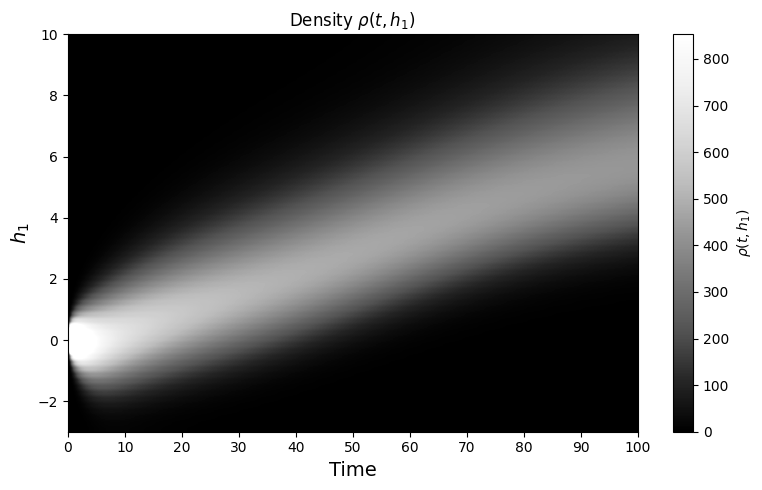

In [7]:
import numpy as np
import copy
T=100
print(f"\nRunning FP simulation for T={T} seconds")
fp_ctx = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=lambda t, v: 300.0,
    T=T,
    verbose=False
)


plot_fp_density_time_dim(fp_ctx, sol=None, disp_step=10, cmap="Greys_r")







c*(t) at the FP snapshots:
t= 0.000  c*=40.9993
t= 0.020  c*=41.215
t= 0.040  c*=41.4289
t= 0.060  c*=41.6408
t= 0.080  c*=41.8507


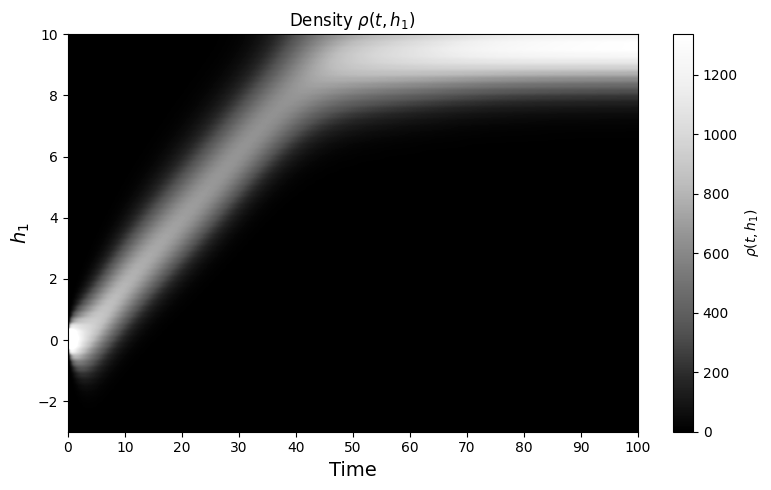

In [ ]:
import numpy as np

# ---------- grid measures (time-invariant) ----------
def _grid_measures(fp_ctx):
    axes  = fp_ctx["axes"]
    N_h   = len(axes)
    d_h   = axes[0][1] - axes[0][0]
    dH    = d_h ** N_h
    h_mesh = np.meshgrid(*axes, indexing="ij")  # list length N_h
    return axes, h_mesh, dH

# ---------- E_stack at a given time index k ----------
def _E_stack_at_k(fp_ctx, k, h_mesh):
    """
    Build E_stack_k[v, ...] = E_v(h, t_k) with S(t_k) from get_S.
    """
    times = fp_ctx["times"]
    get_S = fp_ctx["get_S"]                       # callable: t -> S_mat (N_h, n_A)
    S_k   = get_S(float(times[k]))                # (N_h, n_A)
    E_stack_k = np.tensordot(S_k.T, np.stack(h_mesh, axis=0), axes=(1, 0))
    # shape: (n_A, ...grid...)
    return E_stack_k

# ---------- ⟨log P_Ag + log P_T⟩_pop for a scalar C at time index k ----------
def avg_log_terms_given_C(C, k, fp_ctx, *, kBT, E_a):
    """
    Return <log P_Ag + log P_T>_pop and also (P_Ag + P_T)_pop at snapshot k,
    assuming every antigen has concentration C (scalar).
    """
    axes, h_mesh, dH = _grid_measures(fp_ctx)
    rho     = fp_ctx["rho_t"][k]                       # (...grid...)

    # time-dependent energies via get_S(t_k)
    E_stack = _E_stack_at_k(fp_ctx, k, h_mesh)         # (n_A, ...)

    n_A     = E_stack.shape[0]
    C_vec   = np.full(n_A, float(C), dtype=float)
    C_tot   = C_vec.sum()

    # P_Ag
    exp_term  = np.exp((E_stack - E_a) / kBT)                # (n_A, ...)
    numer     = (C_vec.reshape((n_A,) + (1,)*rho.ndim) * exp_term).sum(axis=0)
    P_Ag      = numer / (1.0 + numer)

    # P_T  (depends only on C_tot)
    Phi       = np.exp(E_stack / kBT).sum(axis=0)            # (...)

    # population-weighted averages
    N_pop     = rho.sum() * dH
    w_pop     = rho / N_pop


    # Gates

    # IMPORTANT: recompute Phi_bar for THIS s2
    Phi_bar  = (w_pop * Phi).sum() * dH
    P_T       = Phi / (Phi + Phi_bar / C_tot)

    avg_log   = (w_pop * (np.log(P_Ag) + np.log(P_T))).sum() * dH
    P_sum_pop = (w_pop * (P_Ag + P_T)).sum() * dH
    return avg_log, P_sum_pop

# ---------- solve c*(t_k) for all snapshots ----------
def solve_c_star_over_time(fp_ctx, *, lam=1.0, kBT, E_a,
                           u0=np.log(1.0), newton_maxit=5, newton_tol=1e-10):
    """
    For each k, solve for c* > 0 such that
        <log P_Ag + log P_T>_pop(C=c*) = -lam
    with time-varying S(t_k).
    Newton in u=log C, derivative: d/du <log P_Ag + log P_T> = 2 - (P_Ag+P_T)_pop.
    """
    times  = fp_ctx["times"]
    K      = len(times)
    c_star = np.empty(K, dtype=float)

    for k in range(K):
        u = float(u0)
        for it in range(newton_maxit):
            avg_log, Psum = avg_log_terms_given_C(np.exp(u), k, fp_ctx, kBT=kBT, E_a=E_a)
            g  = avg_log + lam
            if abs(g) < newton_tol:
                break
            dg = 2.0 - Psum
            step = g / (dg if abs(dg) > 1e-8 else np.sign(dg)*1e-8)
            u   -= step
        else:
            # fallback: bracketing + bisection
            def F(u_): return avg_log_terms_given_C(np.exp(u_), k, fp_ctx, kBT=kBT, E_a=E_a)[0] + lam
            u_lo, u_hi = u - 20.0, u + 20.0
            g_lo, g_hi = F(u_lo), F(u_hi)
            tries = 0
            while g_lo * g_hi > 0 and tries < 30:
                u_lo -= 5.0; u_hi += 5.0
                g_lo, g_hi = F(u_lo), F(u_hi); tries += 1
            for _ in range(10):
                u_mid = 0.5*(u_lo+u_hi); g_mid = F(u_mid)
                if g_mid > 0: u_hi = u_mid
                else:         u_lo = u_mid
            u = 0.5*(u_lo+u_hi)

        c_star[k] = np.exp(u)

    return np.array(times), c_star

times, c_star = solve_c_star_over_time(fp_ctx, lam=lam, kBT=kBT, E_a=E_a)
print("c*(t) at the FP snapshots:")
for t, c in zip(times[:5], c_star[:5]):
    print(f"t={t:6.3f}  c*={c:.6g}")

def make_get_C_from_cstar(times, c_star):
    times = np.asarray(times, dtype=float)
    c_star = np.asarray(c_star, dtype=float)
    t0, tf = float(times[0]), float(times[-1])

    def get_C_star(t, v):
        # same concentration for all antigens v
        t = float(t)
        if t <= t0:
            return float(c_star[0])
        if t >= tf:
            return float(c_star[-1])
        return float(np.interp(t, times, c_star))
    return get_C_star

get_C_star = make_get_C_from_cstar(times, c_star)

fp_ctx = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=get_C_star,
    T=T,
    verbose=False
)


plot_fp_density_time_dim(fp_ctx, sol=None, disp_step=10, cmap="Greys_r")






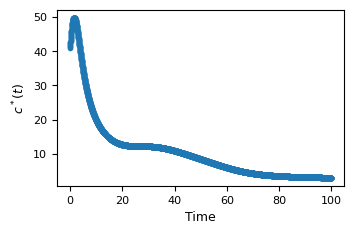

: 

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(3.4, 2.2))  # PRL column width ~3.4 inches
plt.plot(times, c_star, marker='o', markersize=3, lw=1)
plt.xlabel(r"Time", fontsize=9)
plt.ylabel(r"$c^*(t)$", fontsize=9)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout(pad=0.2)
plt.savefig("c_star_vs_time.pdf")  # vector format for publication
plt.show()


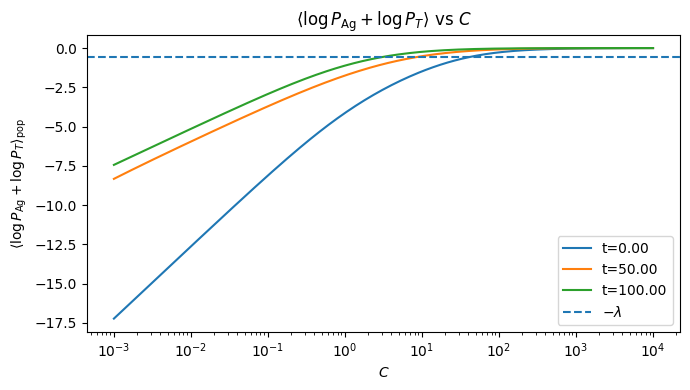

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- helpers ----------
def _grid_measures(fp_ctx):
    axes  = fp_ctx["axes"]
    N_h   = len(axes)
    d_h   = axes[0][1] - axes[0][0]
    dH    = d_h ** N_h
    h_mesh = np.meshgrid(*axes, indexing="ij")
    return axes, h_mesh, dH

def _E_stack_at_k(fp_ctx, k, h_mesh):
    times = fp_ctx["times"]
    get_S = fp_ctx["get_S"]         # t -> S_mat (N_h, n_A)
    S_k   = get_S(float(times[k]))  # (N_h, n_A)
    return np.tensordot(S_k.T, np.stack(h_mesh, axis=0), axes=(1, 0))  # (n_A, ...)

def avg_log_terms_given_C(C, k, fp_ctx, *, kBT, E_a):
    """
    Return <log P_Ag + log P_T>_pop and (P_Ag + P_T)_pop at snapshot k,
    assuming all antigens have the same concentration C (scalar).
    """
    _, h_mesh, dH = _grid_measures(fp_ctx)
    rho     = fp_ctx["rho_t"][k]                       # (...grid...)
    E_stack = _E_stack_at_k(fp_ctx, k, h_mesh)         # (n_A, ...)

    n_A     = E_stack.shape[0]
    C_vec   = np.full(n_A, float(C), dtype=float)
    C_tot   = C_vec.sum()

    # P_Ag
    exp_term  = np.exp((E_stack - E_a) / kBT)                # (n_A, ...)
    numer     = (C_vec.reshape((n_A,) + (1,)*rho.ndim) * exp_term).sum(axis=0)
    P_Ag      = numer / (1.0 + numer)                        # (...)

    # P_T  (uses Phi_bar computed from current rho and S(t_k), independent of C)
    Phi       = np.exp(E_stack / kBT).sum(axis=0)            # (...)
    N_pop     = rho.sum() * dH
    w_pop     = rho / N_pop
    Phi_bar   = (w_pop * Phi).sum() * dH                     # scalar for this k
    P_T       = Phi / (Phi + Phi_bar / C_tot)

    avg_log   = (w_pop * (np.log(P_Ag) + np.log(P_T))).sum() * dH
    P_sum_pop = (w_pop * (P_Ag + P_T)).sum() * dH
    return float(avg_log), float(P_sum_pop)

# ---------- vectorized sweep over C for chosen snapshots ----------
def avg_log_vs_C_for_k(fp_ctx, k, C_grid, *, kBT, E_a):
    vals = np.empty_like(C_grid, dtype=float)
    for i, C in enumerate(C_grid):
        vals[i] = avg_log_terms_given_C(C, k, fp_ctx, kBT=kBT, E_a=E_a)[0]
    return vals

def plot_avg_log_vs_C(fp_ctx, k_list, *, kBT, E_a, lam=None,
                      C_min=1e-1, C_max=1e4, nC=200, logx=True,
                      title=r"$\langle \log P_{\mathrm{Ag}} + \log P_T \rangle$ vs $C$"):
    C_grid = np.logspace(np.log10(C_min), np.log10(C_max), nC) if logx else np.linspace(C_min, C_max, nC)
    plt.figure(figsize=(7, 4))
    for k in k_list:
        vals = avg_log_vs_C_for_k(fp_ctx, k, C_grid, kBT=kBT, E_a=E_a)
        t = float(fp_ctx["times"][k])
        plt.plot(C_grid, vals, label=f"t={t:.2f}")
    if lam is not None:
        plt.axhline(-lam, linestyle="--", label=r"$-\lambda$")
    if logx:
        plt.xscale("log")
    plt.xlabel(r"$C$")
    plt.ylabel(r"$\langle \log P_{\mathrm{Ag}} + \log P_T \rangle_{\text{pop}}$")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()
# choose a few snapshot indices to visualize, e.g. first, middle, last:
K = len(fp_ctx["times"])
k_list = [0, K//2, K-1]

plot_avg_log_vs_C(fp_ctx, k_list, kBT=kBT, E_a=E_a, lam=lam,
                  C_min=1e-3, C_max=1e4, nC=300, logx=True)


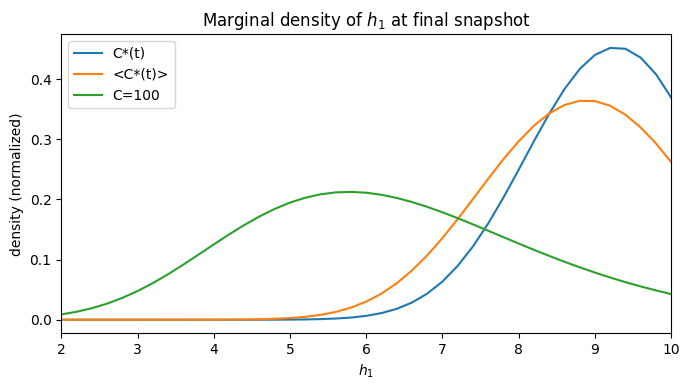

In [50]:
fp_ctx_opt = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=get_C_star,
    T=T,
    verbose=False
)

fp_ctx_mean = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=lambda t,v:c_star.mean(),
    T=T,
    verbose=False
)

fp_ctx_fixed = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=lambda t,v:300,
    T=T,
    verbose=False
)

import numpy as np
import matplotlib.pyplot as plt

def _marginal_h1_pdf(fp_ctx):
    """
    Return (h1_axis, pdf_h1) for the LAST snapshot in fp_ctx.
    Works for N_h >= 1 by integrating out other h-dims.
    """
    axes = fp_ctx["axes"]               # tuple/list of 1D arrays
    N_h  = len(axes)
    h1_axis = axes[0]
    d_h = h1_axis[1] - h1_axis[0]

    rho_last = fp_ctx["rho_t"][-1]      # (...grid...)
    if N_h == 1:
        rho1 = rho_last.copy()
    else:
        # integrate out h2..hN with Riemann sum
        rho1 = rho_last.sum(axis=tuple(range(1, N_h))) * (d_h ** (N_h - 1))

    # normalize to a PDF over h1: ∑ pdf * d_h = 1
    pdf = rho1 / (rho1.sum() * d_h)
    return h1_axis, pdf

# --- get marginals for each schedule ---
h1_opt,   pdf_opt   = _marginal_h1_pdf(fp_ctx_opt)
h1_mean,  pdf_mean  = _marginal_h1_pdf(fp_ctx_mean)
h1_fixed, pdf_fixed = _marginal_h1_pdf(fp_ctx_fixed)

# sanity: same h1 grid
assert np.allclose(h1_opt, h1_mean) and np.allclose(h1_opt, h1_fixed), "h1 grids differ."

# --- plot ---
plt.figure(figsize=(7, 4))
plt.plot(h1_opt,  pdf_opt,   label="C*(t)")
plt.plot(h1_mean, pdf_mean,  label="<C*(t)>")
plt.plot(h1_fixed,pdf_fixed, label="C=100")
plt.xlim(2,10)
plt.xlabel(r"$h_1$")
plt.ylabel("density (normalized)")
plt.title(r"Marginal density of $h_1$ at final snapshot")
plt.legend()
plt.tight_layout()
plt.show()




In [62]:
import numpy as np
import matplotlib.pyplot as plt

def safe_log(x, eps=1e-12):
    return np.log(np.maximum(x, eps))

def _grid_measures(fp_ctx):
    axes  = fp_ctx["axes"]
    N_h   = len(axes)
    d_h   = axes[0][1] - axes[0][0]
    dH    = d_h ** N_h
    h_mesh = np.meshgrid(*axes, indexing="ij")
    return axes, h_mesh, dH

def _E_stack_at_k(fp_ctx, k, h_mesh):
    times = fp_ctx["times"]
    if "get_S" in fp_ctx:
        S_k = fp_ctx["get_S"](float(times[k]))   # (N_h, n_A)
    else:
        S_k = fp_ctx["S_mat"]                    # fallback
    return np.tensordot(S_k.T, np.stack(h_mesh, axis=0), axes=(1, 0)), S_k  # (n_A, ...), (N_h, n_A)

def _coerce_h_vec(h, N_h):
    """If h is scalar and N_h>1, interpret as [h, 0, ..., 0]. If shorter than N_h, pad zeros."""
    if np.isscalar(h):
        vec = np.zeros(N_h, dtype=float); vec[0] = float(h); return vec
    h_arr = np.asarray(h, dtype=float).ravel()
    if h_arr.size == N_h:
        return h_arr
    if h_arr.size < N_h:
        vec = np.zeros(N_h, dtype=float); vec[:h_arr.size] = h_arr; return vec
    # longer than N_h: truncate (or raise if you prefer)
    return h_arr[:N_h]

def gamma_vs_C_from_fp_data(fp_ctx_final, h_vals, C_values, *,
                            kBT, E_a, lam, N_max,
                            t_index=None, t_time=None):
    axes, h_mesh, dH = _grid_measures(fp_ctx_final)
    times = np.asarray(fp_ctx_final["times"], dtype=float)

    # choose snapshot
    if t_index is not None:
        k = int(t_index)
    elif t_time is not None:
        k = int(np.argmin(np.abs(times - float(t_time))))  # nearest time
    else:
        k = len(times) - 1  # default: last

    rho_f = fp_ctx_final["rho_t"][k]
    E_stack, S_final = _E_stack_at_k(fp_ctx_final, k, h_mesh)
    N_h, n_A = S_final.shape

    # ... then use rho_k, E_stack, S_k exactly as before instead of rho_f / S_final ...

    Phi_grid = np.exp(E_stack / kBT).sum(axis=0)

    N_pop   = rho_f.sum() * dH
    w_pop   = rho_f / N_pop
    Phi_bar = (w_pop * Phi_grid).sum() * dH

    fig, ax = plt.subplots(figsize=(6.2, 4))

    for h in h_vals:
        h_vec = _coerce_h_vec(h, N_h)                # <-- key fix here
        E_pt  = (S_final.T @ h_vec).ravel()          # (n_A,)
        Phi_pt = np.exp(E_pt / kBT).sum()
        exp_Es_pt = np.exp((E_pt - E_a) / kBT)

        gamma_vals = []
        for C in C_values:
            C = float(C)
            C_tot = C * n_A

            # population avg at this C
            exp_term_grid = np.exp((E_stack - E_a) / kBT)
            numer_grid    = (C * exp_term_grid).sum(axis=0)
            PAg_grid      = numer_grid / (1.0 + numer_grid)
            PT_grid       = Phi_grid / (Phi_grid + Phi_bar / C_tot)

            avg_log = (w_pop * (safe_log(PAg_grid) + safe_log(PT_grid))).sum() * dH
            Omega   = 0.0 if N_pop < N_max else max(0.0, lam + avg_log)

            # point Γ(C,h)
            numer_pt = (C * exp_Es_pt).sum()
            PAg_pt   = numer_pt / (1.0 + numer_pt)
            PT_pt    = Phi_pt / (Phi_pt + Phi_bar / C_tot)

            gamma_pt = lam + safe_log(PAg_pt) + safe_log(PT_pt) - Omega
            gamma_vals.append(float(gamma_pt))

        ax.plot(C_values, gamma_vals, label=rf"$h={h}$")

    ax.set_xscale("log")
    ax.set_xlabel("concentration $C$")
    ax.set_ylabel(r"$\Gamma(C,h)$")
    ax.set_title(r"$\Gamma(C,h)$ at time "+str(t_time))
    ax.legend()
    plt.tight_layout()
    plt.show()


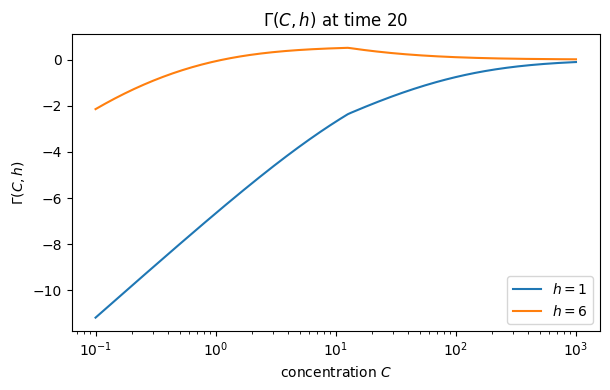

In [63]:
# pick some h points (for N_h=1 these are scalars; for N_h=2 pass vectors like [h1,h2])
h_vals = [1, 6]                 # adjust to your grid’s support
C_grid = np.logspace(-1, 3, 300)   # e.g., 0.1 to 1e3
gamma_vs_C_from_fp_data(fp_ctx, h_vals, C_grid, kBT=kBT, E_a=E_a, lam=lam, N_max=N_max, t_time=20)
